I'm going to make a ML model to predict heart disease.

1. Importing the required libraries

In [47]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve,auc
import joblib


2. Now let's upload the dataset.

In [3]:
# upload the daataset
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()

Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction.csv


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
# get some informations about the dataset
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


3. Preprocess the dataset(According to the ML pipeline)

In [7]:
# identify categorical columns
categorical_features = ['Chest pain type', 'EKG results', 'Slope of ST', 'Thallium', 'Number of vessels fluro']

# apply one hot encoding to categorical columns
# We use drop_first=True to avoid the dummy variable trap
df = pd.get_dummies(df, columns=categorical_features,drop_first=True)

# now let's encode the target variable 'Heart Disease'
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})
df.head()

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Heart Disease,Chest pain type_2,...,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,70,1,130,322,0,109,0,2.4,1,False,...,True,False,True,True,False,False,False,False,False,True
1,67,0,115,564,0,160,0,1.6,0,False,...,False,False,True,True,False,False,True,False,False,False
2,57,1,124,261,0,141,0,0.3,1,True,...,False,False,False,False,False,False,True,False,False,False
3,64,1,128,263,0,105,1,0.2,0,False,...,True,False,False,True,False,False,True,True,False,False
4,74,0,120,269,0,121,1,0.2,0,True,...,False,False,True,False,False,False,False,True,False,False


Now let's do the feature scaling for numerical columns

In [9]:
# define numerical columns
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# apply standard scaler to numerical columns
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df.head()

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Heart Disease,Chest pain type_2,...,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,1.712094,1,-0.075410,1.402212,0,-1.759208,0,1.181012,1,False,...,True,False,True,True,False,False,False,False,False,True
1,1.382140,0,-0.916759,6.093004,0,0.446409,0,0.481153,0,False,...,False,False,True,True,False,False,True,False,False,False
2,0.282294,1,-0.411950,0.219823,0,-0.375291,0,-0.656118,1,True,...,False,False,False,False,False,False,True,False,False,False
3,1.052186,1,-0.187590,0.258589,0,-1.932198,1,-0.743600,0,False,...,True,False,False,True,False,False,True,True,False,False
4,2.152032,0,-0.636310,0.374890,0,-1.240239,1,-0.743600,0,True,...,False,False,True,False,False,False,False,True,False,False


4. Now let's do the model training step.

For that first split the data into train and test data

In [12]:
# Split the data into training and testing
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)



(216, 20)
(54, 20)


Model training using **Logistic Regression**

In [16]:
log = LogisticRegression(random_state=42)
log.fit(X_train,y_train)
log_pred = log.predict(X_test)
log_acc = accuracy_score(y_test,log_pred)
print(classification_report(y_test,log_pred))
print("Accuracy of Logistic regression =",log_acc)

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        33
           1       1.00      0.71      0.83        21

    accuracy                           0.89        54
   macro avg       0.92      0.86      0.88        54
weighted avg       0.91      0.89      0.88        54

Accuracy of Logistic regression = 0.8888888888888888


Model training Using **Decision Tree**

In [23]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test,dt_pred)
print(classification_report(y_test,dt_pred))
print("Accuracy of Decision Tree =",dt_acc)

              precision    recall  f1-score   support

           0       0.71      0.73      0.72        33
           1       0.55      0.52      0.54        21

    accuracy                           0.65        54
   macro avg       0.63      0.63      0.63        54
weighted avg       0.65      0.65      0.65        54

Accuracy of Decision Tree = 0.6481481481481481


Model training Using **Random Forest**

In [24]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test,rf_pred)
print(classification_report(y_test,rf_pred))
print("Accuracy of Random Forest =",rf_acc)

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        33
           1       0.80      0.57      0.67        21

    accuracy                           0.78        54
   macro avg       0.78      0.74      0.75        54
weighted avg       0.78      0.78      0.77        54

Accuracy of Random Forest = 0.7777777777777778


Training the model using **SVM**

In [31]:
svm = SVC(random_state=42,probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test,svm_pred)
print(classification_report(y_test,svm_pred))
print("Accuracy of SVM =",svm_acc)

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        33
           1       0.75      0.71      0.73        21

    accuracy                           0.80        54
   macro avg       0.79      0.78      0.78        54
weighted avg       0.79      0.80      0.80        54

Accuracy of SVM = 0.7962962962962963


Training the model using **KNN**

In [26]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test,knn_pred)
print(classification_report(y_test,knn_pred))
print("Accuracy of KNN =",knn_acc)


              precision    recall  f1-score   support

           0       0.82      0.94      0.87        33
           1       0.88      0.67      0.76        21

    accuracy                           0.83        54
   macro avg       0.85      0.80      0.81        54
weighted avg       0.84      0.83      0.83        54

Accuracy of KNN = 0.8333333333333334


Training the model using **Naive bayes**

In [28]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test,nb_pred)
print(classification_report(y_test,nb_pred))
print("Accuracy of Naive Bayes =",nb_acc)

              precision    recall  f1-score   support

           0       0.81      0.91      0.86        33
           1       0.82      0.67      0.74        21

    accuracy                           0.81        54
   macro avg       0.82      0.79      0.80        54
weighted avg       0.82      0.81      0.81        54

Accuracy of Naive Bayes = 0.8148148148148148


From above accuracy  scores we can see the best model is Logistic regression.  To confirm our observation let's see if the logistic regression model is overfitted or underfitted by plotting training and testing accuracy plots for all the models.

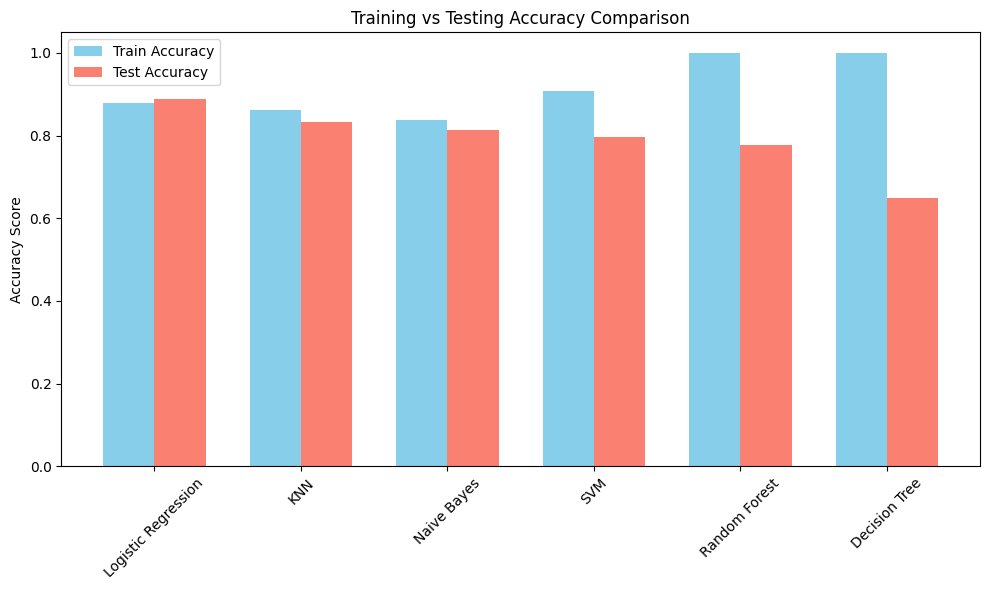

In [40]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

train_accuracies = []
test_accuracies = []
model_names = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Train Accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)

    # Test Accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    model_names.append(name)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# 1. Comparison Plot (Training vs Testing)
plt.figure(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35
plt.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='skyblue')
plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='salmon')
plt.ylabel('Accuracy Score')
plt.title('Training vs Testing Accuracy Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_comparison.png')
plt.show()
plt.close()



By looking at above plot we can determine that the best model is logistic regression model because it's accuracy is high as well as it is the Best Generalized Model. Let's confirm that using confusion matrix.  we can also see that Random forest and Desision tree algorithms are highly overfitted.

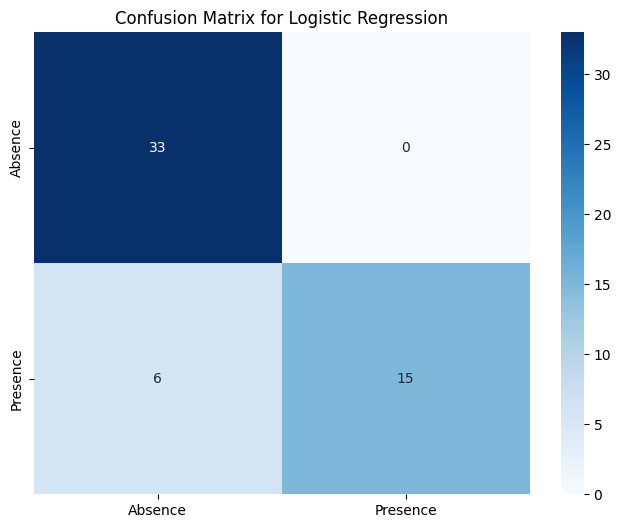

In [41]:
# Confusion matrix for logistic regression
cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Absence', 'Presence'], yticklabels=['Absence', 'Presence'])
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

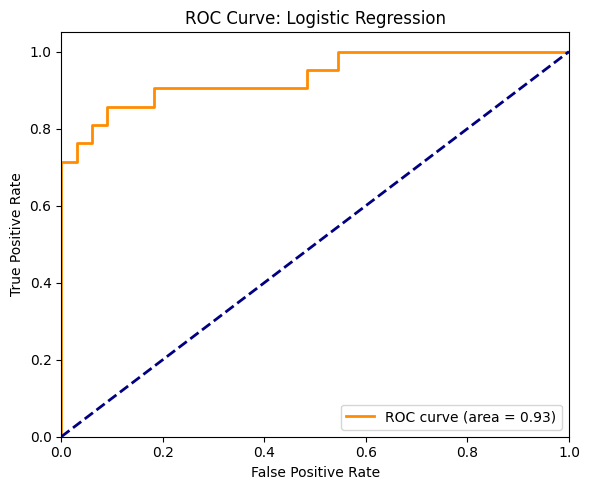

In [46]:
# ROC curve for logistic regression
fpr, tpr, thresholds = roc_curve(y_test, log.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve_lr.png')
plt.show()
plt.close()


The Area Under the Curve (AUC) is 0.91, which is excellent. A score closer to 1.0 means the model has a very high ability to distinguish between patients with and without heart disease.



5. Let's save the model

In [48]:
# Save the logistic regression model
best_model = log
joblib.dump(best_model, 'heart_disease_model.pkl')

#save the Scaler to use it for real-world data
scaler = StandardScaler()
scaler.fit(df[numerical_features])
joblib.dump(scaler, 'scaler.pkl')

# Save the column names (to ensure one-hot encoding matches)
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']